**Table of contents**<a id='toc0_'></a>    
- [How to determine spectral overlap integrals](#toc1_)    
  - [Get emission data of donor and absorption data of acceptor](#toc1_1_)    
  - [Interpolation of missing data points](#toc1_2_)    
  - [Calculation of spectral overlap integrals and FRET rate](#toc1_3_)    
  - [Example: CFP and YFP](#toc1_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[How to determine spectral overlap integrals](#toc0_)

In [ ]:
import numpy as np
import pandas as pd

import fluopy.figure as fi
import fluopy.formulas as fo
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
fluopy.figure version: 0.1.0
fluopy.formulas version: 0.1.0
fluopy.transitions version: 0.1.0


## <a id='toc1_1_'></a>[Get emission data of donor and absorption data of acceptor](#toc0_)

In [ ]:
cy5_emission_path = r"C:\Users\vie43sq\data_vincent\GitHub\Photoswitching\src\fluopy\fluorophore_spectra\cy5_data\emission.csv"
cy5_emission_data = pd.read_csv(cy5_emission_path)
cy5_absorption_path = r"C:\Users\vie43sq\data_vincent\GitHub\Photoswitching\src\fluopy\fluorophore_spectra\cy5_data\absorption_s0.csv"
cy5_absorption_data = pd.read_csv(cy5_absorption_path)

## <a id='toc1_2_'></a>[Interpolation of missing data points](#toc0_)

array([[<Axes: title={'center': 'absorption'}, xlabel='wavelength [nm]', ylabel='$\\epsilon\\ [M^{-1}cm^{-1}]$'>]],
      dtype=object)

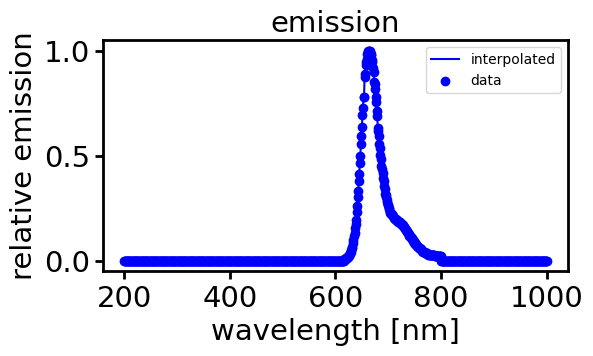

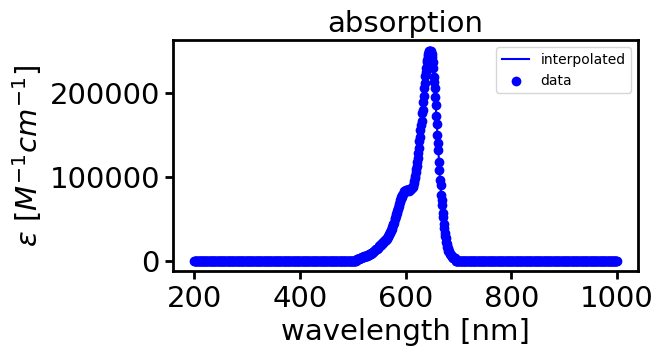

In [9]:
minimum_wavelength, maximum_wavelength = 200, 1000
wavelengths_of_interest = np.arange(
    minimum_wavelength, maximum_wavelength + 1, 1, dtype=float
)
interpolated_em = tr.interpolate_data(
    minimum_wavelength=minimum_wavelength,
    maximum_wavelength=maximum_wavelength,
    data=cy5_emission_data,
)
interpolated_abs = tr.interpolate_data(
    minimum_wavelength=minimum_wavelength,
    maximum_wavelength=maximum_wavelength,
    data=cy5_absorption_data,
)

axes = fi.universal_figure(
    type_="line", data=[wavelengths_of_interest, interpolated_em], label="interpolated"
)
fi.universal_figure(
    type_="scatter",
    data=[cy5_emission_data["Wavelengths"], cy5_emission_data["y"]],
    axes=axes[0],
    label="data",
    legend=True,
    title="emission",
    ylabel="relative emission",
    xlabel="wavelength [nm]",
)
axes = fi.universal_figure(
    type_="line", data=[wavelengths_of_interest, interpolated_abs], label="interpolated"
)
fi.universal_figure(
    type_="scatter",
    data=[cy5_absorption_data["Wavelengths"], cy5_absorption_data["y"]],
    axes=axes[0],
    label="data",
    legend=True,
    title="absorption",
    ylabel=r"$\epsilon\ [M^{-1}cm^{-1}]$",
    xlabel="wavelength [nm]",
)

## <a id='toc1_3_'></a>[Calculation of spectral overlap integrals and FRET rate](#toc0_)

In [12]:
J = fo.calculate_spectral_overlap_integral(
    donor=interpolated_em,
    acceptor=interpolated_abs,
    wavelengths=wavelengths_of_interest,
)
r_FRET = fo.calculate_fret_rate(
    distance=10,
    emission_rate=1e8,
    spectral_overlap_integral=J,
    dipole_orientation_factor=2 / 3,
    refractive_index=1,
)
print(f"J: {J:.2e}")
print(f"r_FRET: {r_FRET:.2e}")

J: 1.57e+16
r_FRET: 9.19e+07


## <a id='toc1_4_'></a>[Example: CFP and YFP](#toc0_)

J: 1.44e+15
r_FRET: 3.69e+09


array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

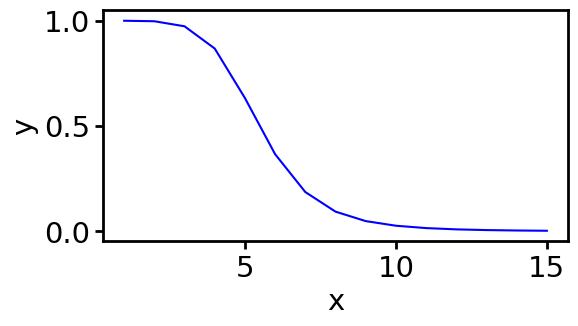

In [43]:
cfp_wavelengths = np.arange(400, 800, 10, dtype=float)
cfp_emission = np.zeros(cfp_wavelengths.shape, dtype=float)
a = np.array(
    [
        0,
        0,
        0,
        0,
        0,
        5,
        40,
        90,
        98,
        88,
        95,
        90,
        74,
        60,
        50,
        40,
        30,
        20,
        10,
        0,
    ]
)
cfp_emission[:20] = a
cfp_emission /= 100

yfp_absorption = np.zeros(cfp_wavelengths.shape, dtype=float)
b = np.array(
    [
        0,
        0,
        0,
        0,
        0,
        5,
        10,
        20,
        33,
        42,
        58,
        94,
        83,
        20,
        10,
        0,
        0,
        0,
        0,
        0,
    ]
)
yfp_absorption[:20] = b * 57000 / 100

J = fo.calculate_spectral_overlap_integral(
    donor=cfp_emission,
    acceptor=yfp_absorption,
    wavelengths=cfp_wavelengths,
)

efficiencies = []
for distance in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]:
    r_FRET = fo.calculate_fret_rate(
        distance=distance,
        emission_rate=1e8,
        spectral_overlap_integral=J,
        dipole_orientation_factor=2 / 3,
        refractive_index=1.33,
    )
    if distance == 3:
        print(f"J: {J:.2e}")
        print(f"r_FRET: {r_FRET:.2e}")
    fret_efficiency = fo.calculate_fret_efficiency(
        r_FRET,
        1e-8,
    )
    efficiencies.append(fret_efficiency)

fi.universal_figure(
    data=[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], efficiencies]
)